This notebook reads in the raw file output from the EM31 and EM34 data loggers.

It will do some simple associatations for each data point in the files:
* It will interpolate GPS positions for each point
* It will convert the readings into mS/m (quadrature) or ppt (in-phase) of Vs/Vp, for the quadrature and in-phase components.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import datetime
import pandas as pd
import zoneinfo

In [14]:
tzone = zoneinfo.ZoneInfo('America/Denver')

In [15]:
EM31_dat_files = glob("data/labEM3/raw/*.P38")
EM31_dat_files.sort()
EM31_dat_files

['data/labEM3/raw/012422A.P38',
 'data/labEM3/raw/012422b.P38',
 'data/labEM3/raw/012422c.P38',
 'data/labEM3/raw/012423d.P38',
 'data/labEM3/raw/012423e.P38']

In [54]:
def parse_em31_file(file_name):
    with open(file_name,'rb') as f:
        lines = f.readlines()
    lines = [line.strip() for line in lines]

    # parse the first two header lines about file information
    line = lines[0].decode('ascii')
    program_file = line[0:7]
    program_version = line[8:12]
    survey_type = line[12:15]
    unit_type = "meters" if line[15] == 0 else "feet"
    dipole_mode = {0:"Vertical", 1:"Horizontal"}[int(line[16])]
    survey_mode = {0:"Auto", 1:"Wheel", 2:"Manual"}[int(line[17])]
    components = {0:"Both", 1:"Inphase"}[int(line[18])]

    # second file header line
    line = lines[1].decode('ascii')
    file_name = line[2:10].strip()
    sampling = line[11:18].strip()
    if survey_mode == "Auto":
        sampling = f"Time increment: {sampling} s"
    elif survey_mode == "Wheel":
        sampling = f"Wheel increment: {sampling} {unit_type}"
    elif survey_mode == "Manual":
        sampling = f"Samples per reading: {sampling}"
    else:
        pass

    record_data = []
    gps_data = []

    t_start = None

    i = 2
    while i < len(lines):
        line = lines[i]
        iden = chr(line[0])

        if iden == 'L':
            # Survey line start header
            line = line.decode()
            line_name = line[1:9].strip()

            i += 1
            line = lines[i].decode()
            station = float(line[1:12])

            i += 1
            line = lines[i].decode()
            direction = line[1]
            station_increment = float(line[8:18])

            i += 1
            line = lines[i].decode()
            date = line[1:9]
            dd, mm, yyyy = date[:2], date[2:4], date[4:8]
            date = datetime.date(day=int(dd), month=int(mm), year=int(yyyy))
            time_stamp = line[10:18]
        elif iden == "*":
            line = line.decode()
            # Timer relation:
            computer_time = line[1:13].strip()
            comp_t_start = int(line[13:23].strip())
        elif iden == "T" or iden == "2":
            # skip lines before the first gps reading
            # Reading!
            Gn = bin(line[1])[2:]
            marker = Gn[1]
            mode = Gn[2]
            range3 = Gn[5]
            range2 = Gn[6]
            app_cond = int(line[2:7])
            in_phase = int(line[7:12])

            line = line[2:].decode()
            read1 = line[0:5]
            read2 = line[5:10]
            time_stamp = int(line[10:21].strip())
            
            if t_start is not None:
                dt = datetime.timedelta(microseconds=time_stamp - t_start)

                record_line = [line_name, station, utc_datetime + dt, time_stamp]
            else:
                record_line = [line_name, station, None, time_stamp]

            if components == "Both":
                if range3 == 1:
                    if range2 == 1:
                        #1000 sensitivity
                        cond_factor = -0.25
                    else:
                        cond_factor = -0.025
                else:
                    cond_factor = -0.0025
                in_factor = -0.025
    
                cond = cond_factor * int(read1)
                inph = in_factor * int(read2)
                record_line.extend([cond, inph])
            else:
                if range3 == 1:
                    if range2 == 1:
                        #1000 sensitivity
                        in_factor = -0.0625
                    else:
                        in_factor = -0.00625
                else:
                    in_factor = -0.000625
                inph = in_factor * read1
                record_line.append([inph])

            record_data.append(record_line)

        elif iden == "C":
            # comment line
            line = line.decode()
            comment = line[1:12]
            time_stamp = int(line[13:23])
        elif iden == "S":
            # New station
            line = line.decode()
            station = float(line[1:12])
            time_stamp = int(line[13:23])
        elif iden == "@":
            # GPS Data message record
            gps_message = line[1:].decode().strip()

            while iden != "!":
                i += 1
                line = lines[i]
                iden = chr(line[0])
                gps_message += line[1:].decode().strip()
            t_start = int(line[13:23].decode())

            gps_info = gps_message.split(",")
            if gps_info[0] != "$GPGGA":
                raise NotImplementedError("Only GGA works for now")
            utc_time = gps_info[1]
            utc_time = datetime.time.fromisoformat(utc_time)
            utc_datetime = datetime.datetime.combine(date, utc_time, datetime.timezone.utc)
            utc_datetime = utc_datetime.astimezone(tzone)
            lat = gps_info[2]
            lat = int(lat[:2]) + float(lat[2:])/60
            lat_ns = gps_info[3]
            if lat_ns == "S":
                lat *= -1
            lon = gps_info[4]
            lon = int(lon[:3]) + float(lon[3:])/60
            lon_ew = gps_info[5]
            if lon_ew == "W":
                lon *= -1
            quality = gps_info[6]
            altitude = float(gps_info[9])
            alt_units = gps_info[10]

            gps_data.append([lat, lon, altitude, utc_datetime, t_start])
            
        i += 1

    record_data = pd.DataFrame(record_data).rename(
        columns={0: "Line number", 1:"Station number", 2:"Datetime",
                 3:"time stamp (ms)", 4:"conductivity (mS/m)", 5:"In-phase (ppt)"}
    )

    gps_data = pd.DataFrame(gps_data).rename(columns={
        0:"Latitude (deg)", 1:"Longitude (deg)", 2:"Altitude (m)", 3:"Datetime", 4:"time stamp (ms)"
    })

    record_data['Latitude (deg)'] = np.interp(
        record_data["time stamp (ms)"], gps_data['time stamp (ms)'], gps_data['Latitude (deg)']
    )
    record_data['Longitude (deg)'] = np.interp(
        record_data["time stamp (ms)"], gps_data['time stamp (ms)'], gps_data['Longitude (deg)']
    )
    record_data['Altitude (m)'] = np.interp(
        record_data["time stamp (ms)"], gps_data['time stamp (ms)'], gps_data['Altitude (m)']
    )

    return record_data

In [51]:
d0 = parse_file(EM31_dat_files[0])
d1 = parse_file(EM31_dat_files[1])
#d2 = parse_file(EM31_dat_files[2])
d3 = parse_file(EM31_dat_files[3])
d4 = parse_file(EM31_dat_files[4])

In [52]:
em31_dat = pd.concat([d0, d1, d3, d4])

In [53]:
em31_dat.to_csv('EM-31_data.csv')

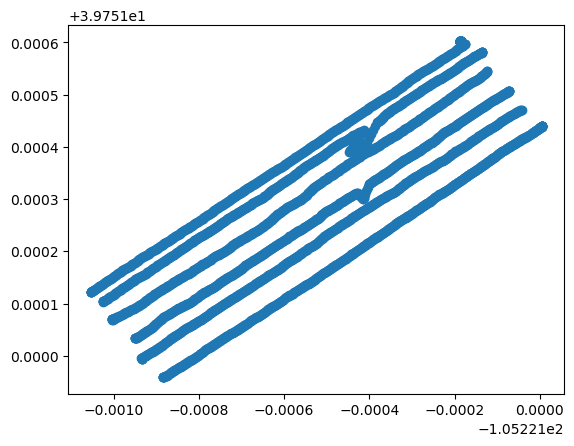

In [39]:
plt.scatter(d1['Longitude (deg)'], d1['Latitude (deg)'])

In [68]:
def parse_em34_file(file_name):
    with open(file_name,'rb') as f:
        lines = f.readlines()
    lines = [line.strip() for line in lines]

    # parse the first two header lines about file information
    line = lines[0].decode('ascii')
    program_file = line[0:7]
    program_version = line[8:12]
    survey_type = line[12:15]
    unit_type = "meters" if line[15] == 0 else "feet"
    configuration = {
        0:"Vertical & 10m", 1:"Vertical & 20m", 2:"Vertical & 40m", 
        0:"Horizontal & 10m", 1:"Horizontal & 20m", 2:"Horizontal & 40m"
    }[int(line[16])]
    survey_mode = {0:"Auto", 1:"Wheel", 2:"Manual"}[int(line[17])]

    # second file header line
    line = lines[1].decode('ascii')
    file_name = line[2:10].strip()
    sampling = line[11:18].strip()
    if survey_mode == "Auto":
        sampling = f"Time increment: {sampling} s"
    elif survey_mode == "Wheel":
        sampling = f"Wheel increment: {sampling} {unit_type}"
    elif survey_mode == "Manual":
        sampling = f"Samples per reading: {sampling}"
    else:
        pass

    record_data = []
    gps_data = []

    t_start = None

    i = 2
    while i < len(lines):
        line = lines[i]
        iden = chr(line[0])

        if iden == 'L':
            # Survey line start header
            line = line.decode()
            line_name = line[1:9].strip()

            i += 1
            line = lines[i].decode()
            station = float(line[1:12])

            i += 1
            line = lines[i].decode()
            direction = line[1]
            station_increment = float(line[8:18])

            i += 1
            line = lines[i].decode()
            date = line[1:9]
            dd, mm, yyyy = date[:2], date[2:4], date[4:8]
            date = datetime.date(day=int(dd), month=int(mm), year=int(yyyy))
            time_stamp = line[10:18]
        elif iden == "*":
            line = line.decode()
            # Timer relation:
            computer_time = datetime.time.fromisoformat(line[1:13].strip())
            utc_datetime = datetime.datetime.combine(date, computer_time)
            t_start = int(line[13:23].strip())
        elif iden == "T" or iden == "2":
            # skip lines before the first gps reading
            # Reading!
            Gn = bin(line[1])[2:]
            marker = int(Gn[1])
            mode = Gn[2]
            sep3 = Gn[3]
            sep2 = Gn[4]
            range3 = Gn[5]
            range2 = Gn[6]
            app_cond = int(line[2:7])
            in_phase = int(line[7:12])

            line = line[2:].decode()
            read1 = line[0:5]
            read2 = line[5:10]
            time_stamp = int(line[10:21].strip())

            if range3 == 1:
                if range2 == 1:
                    #1000 sensitivity
                    cond_factor = -0.25
                else:
                    cond_factor = -0.025
            else:
                cond_factor = -0.0025
            in_factor = -0.025

            cond = cond_factor * int(read1)
            
            if t_start is not None:
                dt = datetime.timedelta(microseconds=time_stamp - t_start)
                dt = utc_datetime + dt
            else:
                dt = None
            record_line = [line_name, station, marker, dt, time_stamp, cond]
            record_data.append(record_line)

        elif iden == "C":
            # comment line
            line = line.decode()
            comment = line[1:12]
            time_stamp = int(line[13:23])
        elif iden == "S":
            # New station
            line = line.decode()
            station = float(line[1:12])
            time_stamp = int(line[13:23])
        elif iden == "@":
            # GPS Data message record
            gps_message = line[1:].decode().strip()

            while iden != "!":
                i += 1
                line = lines[i]
                iden = chr(line[0])
                gps_message += line[1:].decode().strip()
            t_start = int(line[13:23].decode())

            gps_info = gps_message.split(",")
            if gps_info[0] != "$GPGGA":
                raise NotImplementedError("Only GGA works for now")
            utc_time = gps_info[1]
            utc_time = datetime.time.fromisoformat(utc_time)
            utc_datetime = datetime.datetime.combine(date, utc_time, datetime.timezone.utc)
            utc_datetime = utc_datetime.astimezone(tzone)
            lat = gps_info[2]
            lat = int(lat[:2]) + float(lat[2:])/60
            lat_ns = gps_info[3]
            if lat_ns == "S":
                lat *= -1
            lon = gps_info[4]
            lon = int(lon[:3]) + float(lon[3:])/60
            lon_ew = gps_info[5]
            if lon_ew == "W":
                lon *= -1
            quality = gps_info[6]
            altitude = float(gps_info[9])
            alt_units = gps_info[10]

            gps_data.append([lat, lon, altitude, utc_datetime, t_start])
            
        i += 1

    record_data = pd.DataFrame(record_data).rename(
        columns={0: "Line number", 1:"Station number", 2:"marked", 3:"Datetime",
                 4:"time stamp (ms)", 5:"conductivity (mS/m)"}
    )

    return record_data

In [69]:
em34 = parse_em34_file('data/labEM3/raw/34.R34')
em34

,Line number,Station number,marked,Datetime,time stamp (ms),conductivity (mS/m)
0,0,0.0,0,2025-01-24 13:57:42.005714,80494737,20.4775
1,0,0.0,0,2025-01-24 13:57:42.005904,80494927,20.4775
2,0,0.0,0,2025-01-24 13:57:42.006095,80495118,20.4775
3,0,0.0,0,2025-01-24 13:57:42.006286,80495309,20.4775
4,0,0.0,0,2025-01-24 13:57:42.006476,80495499,20.4775
...,...,...,...,...,...,...
2338,0,0.0,0,2025-01-24 13:57:44.845893,83334916,20.4775
2339,0,0.0,0,2025-01-24 13:57:44.846081,83335104,20.4775
2340,0,0.0,0,2025-01-24 13:57:44.846270,83335293,20.4775
2341,0,0.0,0,2025-01-24 13:57:44.846458,83335481,20.4775


In [71]:
em34.to_csv('data/labEM3/em34.csv')

In [72]:

gem2_files = glob('data/labEM3/Gem2/*.csv')
gem2_files.sort()
gem2_files

['data/labEM3/Gem2/01-xg-29ja-098_gem.csv',
 'data/labEM3/Gem2/02-xg-29ja-188_gem.csv',
 'data/labEM3/Gem2/03-xg-29ja-1a8_gem.csv',
 'data/labEM3/Gem2/04-xg-29ja-009_gem.csv']

In [73]:
gem_frames = [pd.read_csv(f) for f in gem2_files]

In [78]:
gem_record = pd.concat(gem_frames)

In [80]:
gem_record = gem_record.sort_values('Time[ms]')

In [81]:
gem_record.to_csv('data/labEM3/gem2.csv')